# Pandas extended introduction

This notebook offers a more comprehensive overview of Pandas.  


# Section 1: Getting Started With Pandas

We will begin by introducing the `Series`, `DataFrame`, and `Index` classes, which are the basic building blocks of the pandas library, and showing how to work with them. By the end of this section, you will be able to create DataFrames and perform operations on them to inspect and filter the data.

## Anatomy of a DataFrame

A **DataFrame** is composed of one or more **Series**. The names of the **Series** form the column names, and the row labels form the **Index**.

In [ ]:
import pandas as pd

meteorites = pd.read_csv('./data/Meteorite_Landings.csv', nrows=5)
meteorites

*Source: [NASA's Open Data Portal](https://data.nasa.gov/Space-Science/Meteorite-Landings/gh4g-9sfh)*

#### Series:

In [ ]:
meteorites.name

#### Columns:

In [ ]:
meteorites.columns

#### Index:

In [ ]:

meteorites.index

## Creating DataFrames

We can create DataFrames from a variety of sources such as other Python objects, flat files, webscraping, and API requests. Here, we will see just a couple of examples, but be sure to check out [this page](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html) in the documentation for a complete list.

### Using a flat file

In [ ]:
import pandas as pd

meteorites = pd.read_csv('data/Meteorite_Landings.csv')

*Tip: There are many parameters to this function to handle some initial processing while reading in the file &ndash; be sure check out the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).*

### Loading data from an API

Data often arrives from a web **API** rather than a file. This dataset came originally from [NASA's Open Data Portal](https://data.nasa.gov/) via the Socrata (SODA) API. Live endpoints can be slow or change without notice (this one has), so for a notebook that runs reliably offline we load a cached copy from `./data/` below &ndash; the commented code shows the live `requests` pattern you would otherwise use.

In [1]:
import pandas as pd

# This data came from NASA's Socrata API. Live endpoints can be slow or move, so we load
# the cached copy shipped in ./data/. The live pull would have been:
#
#     import requests
#     response = requests.get(
#         'https://data.nasa.gov/resource/gh4g-9sfh.json',
#         params={'$limit': 50_000}, timeout=10,
#     )
#     payload = response.json() if response.ok else None
#
payload = (
    pd.read_csv('./data/Meteorite_Landings.csv')
      .rename(columns={'mass (g)': 'mass', 'GeoLocation': 'geolocation'})
      .to_dict(orient='records')
)

Create the DataFrame with the resulting payload:

In [ ]:
import pandas as pd

df = pd.DataFrame(payload)
df.head(3)

*Tip: `df.to_csv('data.csv')` writes this data to a new file called `data.csv`.*

In [ ]:
df.to_csv('mydata.csv')

## Inspecting the data
Now that we have some data, we need to perform an initial inspection of it. This gives us information on what the data looks like, how many rows/columns there are, and how much data we have.

Let's inspect the `meteorites` data.

#### How many rows and columns are there?

In [ ]:
meteorites.shape

#### What are the column names?

In [ ]:

meteorites.columns

#### What type of data does each column currently hold?

In [ ]:

meteorites.dtypes

#### What does the data look like?

In [ ]:
meteorites.head()

Sometimes there may be extraneous data at the end of the file, so checking the bottom few rows is also important:

In [ ]:
meteorites.tail()

#### Get some information about the DataFrame

In [ ]:
meteorites.info()

## Extracting subsets

A crucial part of working with DataFrames is extracting subsets of the data: finding rows that meet a certain set of criteria, isolating columns/rows of interest, etc. After narrowing down our data, we are closer to discovering insights. This section will be the backbone of many analysis tasks.

#### Selecting columns

We can select columns as attributes if their names would be valid Python variables:

In [ ]:
meteorites.name

If they aren't, we have to select them as keys. However, we can select multiple columns at once this way:

In [ ]:
meteorites[['name','mass (g)']]

#### Selecting rows

In [ ]:
meteorites[100:104]

#### Indexing

We use `iloc[]` to select rows and columns by their position:

In [ ]:
meteorites.iloc[100:104,[0,3,4,6]]

We use `loc[]` to select by name:

In [ ]:
meteorites.loc[100:104,'mass (g)':'year']

#### Filtering with Boolean masks

A **Boolean mask** is a array-like structure of Boolean values &ndash; it's a way to specify which rows/columns we want to select (`True`) and which we don't (`False`).

Here's an example of a Boolean mask for meteorites weighing more than 50 grams that were found on Earth (i.e., they were not observed falling):

In [ ]:
(meteorites['mass (g)'] > 50) & (meteorites.fall == "Found")

**Important**: Take note of the syntax here. We surround each condition with parentheses, and we use bitwise operators (`&`, `|`, `~`) instead of logical operators (`and`, `or`, `not`).

We can use a Boolean mask to select the subset of meteorites weighing more than 1 million grams (1,000 kilograms or roughly 2,205 pounds) that were observed falling:

In [ ]:
meteorites[(meteorites['mass (g)'] > 50) & (meteorites.fall == "Found")]

*Tip: Boolean masks can be used with `loc[]` and `iloc[]`.*

# Section 2: Data Visualization

The human brain excels at finding patterns in visual representations of the data; so in this section, we will learn how to visualize data using pandas along with the Matplotlib and Seaborn libraries for additional features. We will create a variety of visualizations that will help us better understand our data.

## Why is data visualization necessary?

So far, we have focused a lot on summarizing the data using statistics. However, summary statistics are not enough to understand the distribution &ndash; there are many possible distributions for a given set of summary statistics. Data visualization is necessary to truly understand the distribution:

<div style="text-align: center; margin-top: -10px;">
<img width="50%" src="https://raw.githubusercontent.com/stefmolin/data-morph/main/docs/_static/panda-to-star-eased.gif" alt="Data Morph: panda to star" style="min-width: 300px; margin-bottom: -10px;"/>
<div style="margin: auto; margin-top: 10px"><small><em>A set of points forming a panda can also form a star without any significant changes to the summary statistics displayed above. (source: <a href="https://github.com/stefmolin/data-morph">Data Morph</a>)</em></small></div>
</div>

## Plotting with pandas

Plotting in Pandas is usually done with matplotlib (see below) but many of these plotting functions can be called directly from Pandas. 

Once again, we will be working with the TSA traveler throughput data that we cleaned up in the previous section:

In [1]:
import pandas as pd

tsa_melted_holiday_travel = pd.read_csv(
    './data/tsa_melted_holiday_travel.csv',
    parse_dates=True, index_col='date'
)
tsa_melted_holiday_travel.head()

,year,travelers,holiday
date,,,
2019-01-01,2019,2126398.0,New Year's Day
2019-01-02,2019,2345103.0,New Year's Day
2019-01-03,2019,2202111.0,NaN
2019-01-04,2019,2150571.0,NaN
2019-01-05,2019,1975947.0,NaN


## Scatterplot 
One of the more convenient ways to get a quick overview of numeric data in Pandas is with a scatterplot matrix.

array([[<Axes: xlabel='year', ylabel='year'>,
        <Axes: xlabel='travelers', ylabel='year'>],
       [<Axes: xlabel='year', ylabel='travelers'>,
        <Axes: xlabel='travelers', ylabel='travelers'>]], dtype=object)

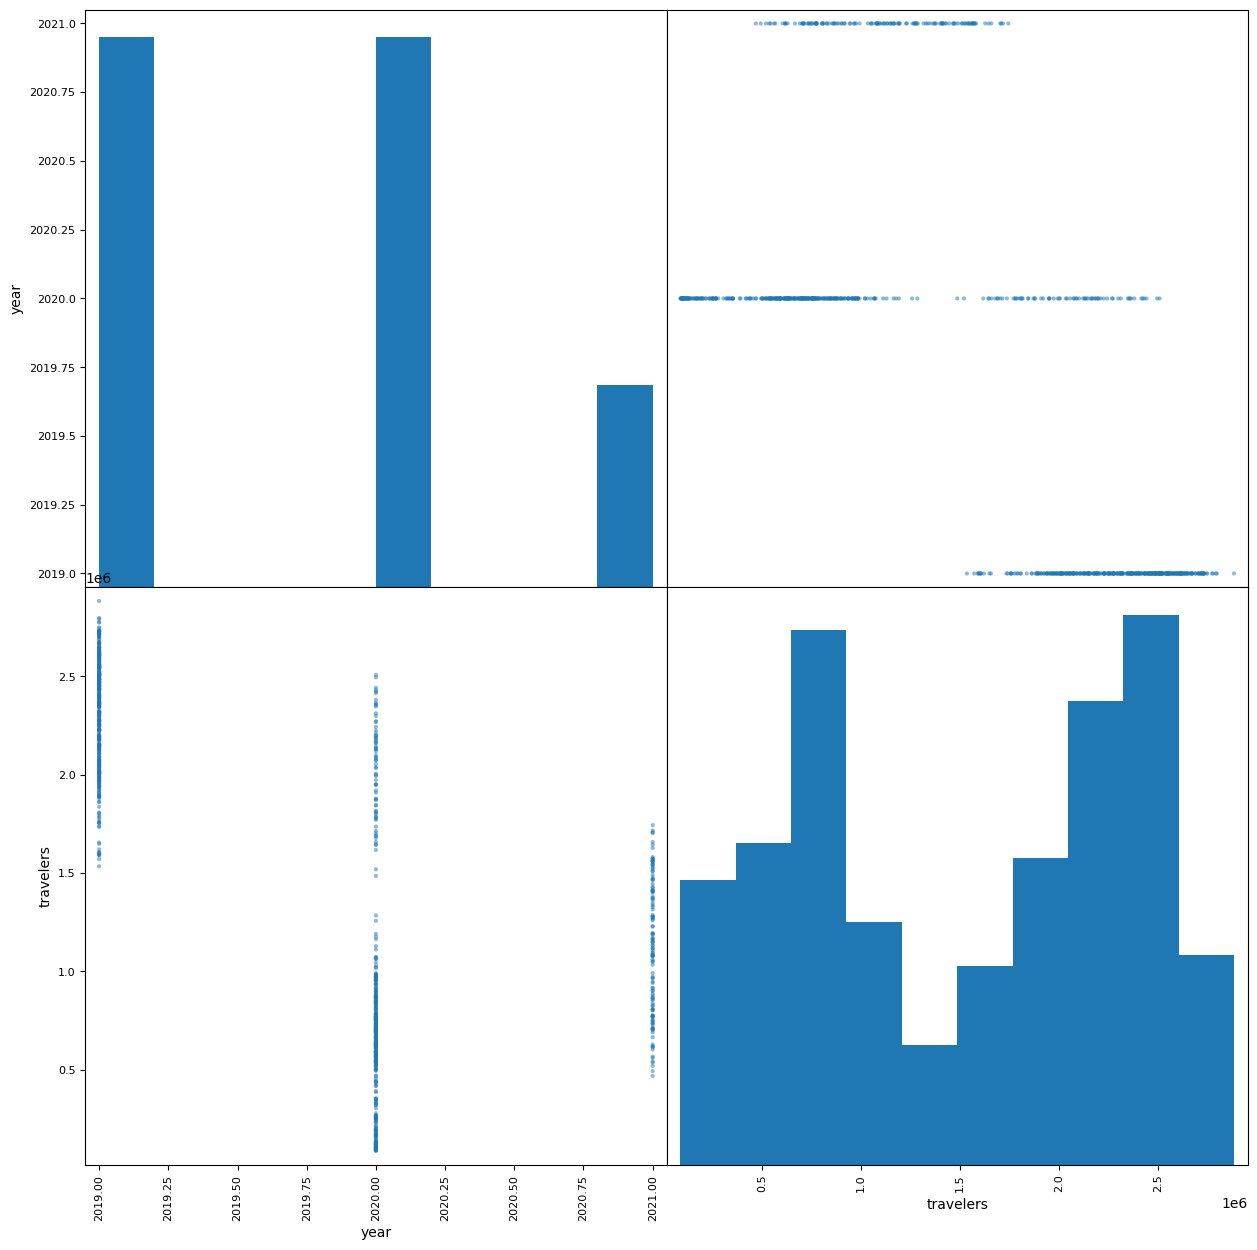

In [3]:
pd.plotting.scatter_matrix(tsa_melted_holiday_travel,figsize=(15,15))



We can create a variety of other visualizations using the `plot()` method. In this section, we will take a brief tour of some of this functionality, which under the hood uses Matplotlib.

### Line plots

The `plot()` method will generate line plots for all numeric columns by default:

In [ ]:
tsa_melted_holiday_travel.drop(columns='year').loc['2020'].assign(
    **{
        '7D MA': lambda x: x.travelers.rolling('7D').mean(),
        'YTD mean': lambda x: x.travelers.expanding().mean()
      }
).plot(title='2020 TSA Traveler Throughput', ylabel='travelers', alpha=0.8)

The `plot()` method returns an `Axes` object that can be modified further (e.g., to add reference lines, annotations, labels, etc.). Let's walk through an example.

### Bar plots

For our next example, we will plot vertical bars to compare monthly TSA traveler throughput across years. Let's start by creating a pivot table with the information we need:

In [ ]:
plot_data = tsa_melted_holiday_travel['2019':'2021-04']\
    .assign(month=lambda x: x.index.month)\
    .pivot_table(index='month', columns='year', values='travelers', aggfunc='sum')
plot_data.head()

We can also look at distributions of using histograms.

<Axes: >

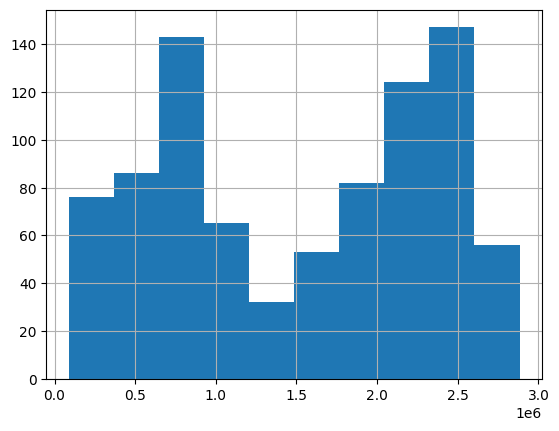

In [5]:
tsa_melted_holiday_travel.travelers.hist()

Note that this is the same as what you see in the scatter matrix, but you can look at subsets of data with the 'by' keyword.

array([[<Axes: title={'center': 'Christmas Day'}>,
        <Axes: title={'center': 'Christmas Eve'}>,
        <Axes: title={'center': 'July 4th'}>],
       [<Axes: title={'center': 'Labor Day'}>,
        <Axes: title={'center': 'Memorial Day'}>,
        <Axes: title={'center': "New Year's Day"}>],
       [<Axes: title={'center': "New Year's Eve"}>,
        <Axes: title={'center': 'Thanksgiving'}>, <Axes: >]], dtype=object)

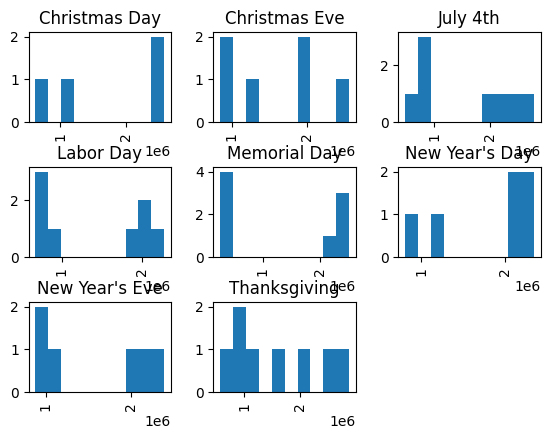

In [7]:
tsa_melted_holiday_travel[["holiday","travelers"]].hist(by="holiday")

Pandas offers other plot types via the `kind` parameter, so we specify `kind='bar'` when calling the `plot()` method. Then, we further format the visualization using the `Axes` object returned by the `plot()` method:

In [ ]:
import calendar
from matplotlib import ticker

ax = plot_data.plot(
    kind='bar', rot=0, xlabel='', ylabel='travelers',
    figsize=(8, 1.5), title='TSA Monthly Traveler Throughput'
)

# use month abbreviations for the ticks on the x-axis
ax.set_xticklabels(calendar.month_abbr[1:])

# show y-axis labels in millions instead of scientific notation
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# customize the legend
ax.legend(title='', loc='center', bbox_to_anchor=(0.5, -0.3), ncols=3, frameon=False)

Some additional things to keep in mind:
- Matplotlib's `ticker` module provides functionality for customizing both the tick labels and locations &ndash; check out the [documentation](https://matplotlib.org/stable/api/ticker_api.html) for more information.
- Pandas supports horizontal and stacked bars as well; [this](https://medium.com/@stefaniemolin/how-to-pivot-and-plot-data-with-pandas-9450939fcf8) blog post shows how to make stacked horizontal bars using a pivot table.
- The `plot()` method takes a lot of [parameters](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html), many of which get passed down to Matplotlib; however, sometimes we need to use Matplotlib calls directly.

### Plotting distributions

Let's now compare the distribution of daily TSA traveler throughput across years. We will create a subplot for each year with both a histogram and a kernel density estimate (KDE) of the distribution.  Pandas has generated the `Figure` and `Axes` objects for both examples so far, but we can build custom layouts by creating them ourselves with Matplotlib using the `plt.subplots()` function. First, we will need to import the `pyplot` module:

In [ ]:

import matplotlib.pyplot as plt

While pandas lets us specify that we want subplots and their layout (with the `subplots` and `layout` parameters, respectively), using Matplotlib to create the subplots directly gives us additional flexibility:

In [ ]:
fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(6, 4))

for year, ax in zip(tsa_melted_holiday_travel.year.unique(), axes):
    plot_data = tsa_melted_holiday_travel.loc[str(year)].travelers
    plot_data.plot(kind='hist', legend=False, density=True, alpha=0.8, ax=ax)
    plot_data.plot(kind='kde', legend=False, color='blue', ax=ax)
    ax.set(title=f'{year} TSA Traveler Throughput', xlabel='travelers')

fig.tight_layout() # handle overlaps

*Tip: If you're new to the `zip()` function, check out [this](https://realpython.com/python-zip-function/) article.*

## Plotting with Seaborn

The Seaborn library provides the means to easily visualize long-format data without first pivoting it. In addition, it also offers some additional plot types &ndash; once again building on top of Mtplotlib. Here, we will look at a few examples of visualizations we can create with Seaborn.

### Visualizing long-format data

With Seaborn, we can specify plot colors according to values of a column with the `hue` parameter. When working with functions that generate subplots, we can also specify how to split the subplots by values of a long-format column with the `col` and `row` parameters. Here, we revisit the comparison of the distribution of TSA traveler throughput across years:

In [ ]:
import seaborn as sns

sns.displot(
    data=tsa_melted_holiday_travel, x='travelers', col='year', kde=True, height=2.5
)

### Heatmaps
We can also use Seaborn to visualize pivot tables as heatmaps:

In [ ]:
data = tsa_melted_holiday_travel['2019':'2021-04']\
    .assign(month=lambda x: x.index.month)\
    .pivot_table(index='month', columns='year', values='travelers', aggfunc='sum')

data

In [ ]:
ax = sns.heatmap(data=data / 1e6, cmap='Blues', annot=True, fmt='.1f')
_ = ax.set_yticklabels(calendar.month_abbr[1:], rotation=0)
_ = ax.set_title('Total TSA Traveler Throughput (in millions)')

*Tip: Reference the Matplotlib documentation for more information on [colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html) and [named colors](https://matplotlib.org/stable/gallery/color/named_colors.html).*

We're moving on from Seaborn now, but there is a lot more available in the [API](https://seaborn.pydata.org/api.html). Be sure to check out the following at a minimum:
- [pairwise plots](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) with `pairplot()`
- [categorical scatter plots](https://seaborn.pydata.org/generated/seaborn.swarmplot.html#seaborn.swarmplot) with `swarmplot()`
- [joint distribution plots](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot) with `jointplot()`
- [FacetGrids](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html#seaborn.FacetGrid) for custom layouts with any plot type

## Customizing plots with Matplotlib

In this final section, we will discuss how to use Matplotlib to customize plots. Since there is a lot of functionality available, we will only be covering how to add shaded regions and annotations here, but be sure to check out the [documentation](https://matplotlib.org/) for more.

### Adding shaded regions

When looking at a plot of TSA traveler throughput over time, it's helpful to indicate periods during which there was holiday travel. We can do so with the `axvspan()` method:

In [ ]:
plot_data = tsa_melted_holiday_travel['2019-05':'2019-11']
ax = plot_data.travelers.plot(
    title='TSA Traveler Throughput', ylabel='travelers', figsize=(9, 2)
)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# collect the holiday ranges (start and end dates)
holiday_ranges = plot_data.dropna().reset_index()\
    .groupby('holiday').agg({'date': ['min', 'max']})

# create shaded regions for each holiday in the plot
for start_date, end_date in holiday_ranges.to_numpy():
    ax.axvspan(start_date, end_date, color='gray', alpha=0.2)

*Tip: Use `axhspan()` for horizontally shaded regions and `axvline()` / `axhline()` for vertical/horizontal reference lines.*

### Adding annotations

We can use the `annotate()` method to add annotations to the plot. Here, we point out the day in 2019 with the highest TSA traveler throughput, which was the day after Thanksgiving:

In [ ]:
plot_data = tsa_melted_holiday_travel.loc['2019']
ax = plot_data.travelers.plot(
    title='TSA Traveler Throughput', ylabel='travelers', figsize=(9, 2)
)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# highest throughput
max_throughput_date = plot_data.travelers.idxmax()
max_throughput = plot_data.travelers.max()
_ = ax.annotate(
    f'{max_throughput_date:%b %d}\n({max_throughput / 1e6:.2f} M)',
    xy=(max_throughput_date, max_throughput),
    xytext=(max_throughput_date - pd.Timedelta(days=25), max_throughput * 0.92),
    arrowprops={'arrowstyle': '->'}, ha='center'
)

Some things to keep in mind:
- We used `Axes` methods to customize our plots (i.e., an object-oriented approach), but the `pyplot` module provides equivalent functions (i.e., a functional approach) for adding shaded regions, reference lines, annotations, etc. &ndash; although the function names might be slightly different than their `Axes` method counterparts (e.g., `Axes.set_xlabel()` vs. `plt.xlabel()`).
- In general, try to stick to either the object-oriented or functional approach rather than mixing the two. However, be careful when working with subplots &ndash; `pyplot` functions will only affect the last subplot.
- The [anatomy of a figure](https://matplotlib.org/stable/gallery/showcase/anatomy.html) diagram in the Matplotlib documentation is a great resource for identifying which objects you will need to access for plot customizations.

# Section 3: More advanced Pandas

## Calculating summary statistics

In the next section of this workshop, we will discuss data cleaning for a more meaningful analysis of our datasets; however, we can already extract some interesting insights from the `meteorites` data by calculating summary statistics.

#### How many of the meteorites were found versus observed falling?

In [ ]:
meteorites.fall.value_counts(normalize=True)

*Tip: Pass in `normalize=True` to see this result as percentages. Check the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) for additional functionality.*

#### What was the mass of the average meterorite?

In [ ]:
meteorites['mass (g)'].mean()

**Important**: The mean isn't always the best measure of central tendency. If there are outliers in the distribution, the mean will be skewed. Here, the mean is being pulled higher by some very heavy meteorites &ndash; the distribution is [right-skewed](https://www.analyticsvidhya.com/blog/2020/07/what-is-skewness-statistics/).

Taking a look at some quantiles at the extremes of the distribution shows that the mean is between the 95th and 99th percentile of the distribution, so it isn't a good measure of central tendency here:

In [ ]:
meteorites['mass (g)'].quantile([.01,.05,.5,.95,.99])

A better measure in this case is the median (50th percentile), since it is robust to outliers:

In [ ]:
meteorites['mass (g)'].median()

#### What was the mass of the heaviest meteorite?

In [ ]:
meteorites['mass (g)'].max()

Let's extract the information on this meteorite:

In [ ]:
meteorites.loc[meteorites['mass (g)'].idxmax()]

#### How many different types of meteorite classes are represented in this dataset?

In [ ]:
meteorites.recclass.nunique()

Some examples:

In [ ]:
meteorites.recclass.unique()[:14]

*Note: All fields preceded with "rec" are the values recommended by The Meteoritical Society. Check out [this Wikipedia article](https://en.wikipedia.org/wiki/Meteorite_classification) for some information on meteorite classes.*

#### Get some summary statistics on the data itself
We can get common summary statistics for all columns at once. By default, this will only be numeric columns, but here, we will summarize everything together:

In [ ]:
meteorites.describe(include="all")

**Important**: `NaN` values signify missing data. For instance, the `fall` column contains strings, so there is no value for `mean`; likewise, `mass (g)` is numeric, so we don't have entries for the categorical summary statistics (`unique`, `top`, `freq`).

#### Check out the documentation for more descriptive statistics:

- [Series](https://pandas.pydata.org/docs/reference/series.html#computations-descriptive-stats)
- [DataFrame](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)